# TP TNS n°1 — Synthèse de filtres FIR par la méthode des fenêtres (*BOUAFIF Rayen*)
**Objectif :** Ce TP porte sur la conception de filtres numériques à réponse impulsionnelle finie (FIR), en utilisant la méthode des fenêtres.
Deux types de filtres sont conçus et validés sur un signal test :
* **Un filtre passe-bas** (fc = 4000 Hz)
* **Un filtre passe-bande** (centré sur 7500 Hz)

## Imports et paramètres globaux

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.fftpack import fft

# ── Style (Pour Affichage) ──────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': '#F8F9FA',
    'axes.grid': True, 'grid.linestyle': '--', 'grid.linewidth': 0.5,
    'grid.color': '#DEE2E6', 'lines.linewidth': 1.8,
    'font.size': 10, 'axes.titlesize': 11, 'axes.titleweight': 'bold',
})
C = dict(ideal='#1f77b4', rect='#ff7f0e', hamming='#2ca02c', pb='#d62728',
         signal='#3a919b', filt='#9467bd')

# ── Paramètres globaux ───────────────────────────────────────────────────────────────────────
fe   = 20_000          # fréquence d'échantillonnage [Hz]
Np   = 128             # nombre d'échantillons 
Nf   = 4096            # résolution fréquentielle (pour FFT)
A1, f1 = 4,  3000      # composante 1 du signal d'entrée
A2, f2 = 10, 7500      # composante 2 du signal d'entrée
fc   = 4_000           # fréquence de coupure passe-bas (Filtre 1) [Hz]
fcr  = fc / fe         # fréquence réduite = 0.20
eps  = 1e-10

# ── Fonctions utilitaires (à utiliser après dans les cellules de test) ────────────────────────────────────────────────────────────────────
def sinc_coeff(k, fcr):
    """FFT-1 (G(f)) = g(k) = 2·fcr·sinc(2·fcr·k) avec sinc(x) = sin(πx)/(πx) et sinc(0)=1."""
    return 2 * fcr * np.sinc(2 * fcr * k)

def make_fir(N, fcr, window='rect'):
    """Construit h(n) causal de longueur N (N impair).
    Retourne h (coefficients causaux), gw (réponse non-causale), k_nc (indices non-causaux)."""
    assert N % 2 == 1, 'N doit être impair'
    M  = (N - 1) // 2
    k  = np.arange(-M, M + 1)       # indices non-causaux
    g  = sinc_coeff(k, fcr)          # réponse idéale
    if window == 'hamming':
        w = 0.54 + 0.46 * np.cos(2 * np.pi * k / (N - 1))
    else:                             # rectangulaire
        w = np.ones(N)
    gw = g * w                        # troncature
    h  = gw.copy()                    # h(n) causal = gw décalé de M (même tableau)
    return h, gw, k

def freq_response(h, Nf=4096):
    """Réponse fréquentielle d'un filtre causal h(n).
    Retourne f_red (fréquences réduites 0..0.5), |H|, phase."""
    H  = np.fft.fft(h, Nf)
    f  = np.fft.fftfreq(Nf)          # fréquences réduites
    # on garde 0..0.5
    idx = f >= 0
    return f[idx], np.abs(H[idx]), np.angle(H[idx])

def filtre_fir(x, h):
    """Convolution (filtrage FIR) — équivalent de np.convolve en mode 'full', tronqué à len(x)."""
    N  = len(h)
    nx = len(x)
    y  = np.zeros(nx)
    for n in range(nx):
        for k in range(N):
            if n - k >= 0:
                y[n] += h[k] * x[n - k]
    return y

print(f'fcr = fc/fe = {fc}/{fe} = {fcr}')

fcr = fc/fe = 4000/20000 = 0.2


## 0. Signal d'entrée $x(n)$ 

Le signal de test est composé de deux sinusoïdes échantillonnées à $f_e = 20$ kHz :
- une composante à **3000 Hz** d'amplitude 4
- une composante à **7500 Hz** d'amplitude 10

Le signal est échantillonné sur **128 points**, et son analyse spectrale est effectuée par **FFT**.


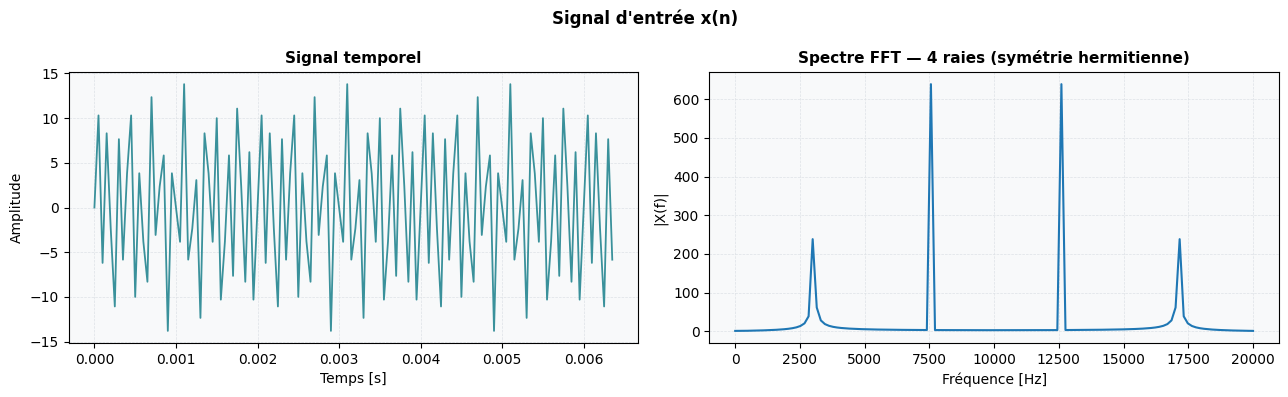

In [3]:
t    = np.linspace(0, Np/fe, Np, endpoint=False)
sig  = A1 * np.sin(2*np.pi*f1*t) + A2 * np.sin(2*np.pi*f2*t)    # Signal d'entrée : somme de 2 sinusoïdes (3 kHz et 7.5 kHz)
np.savetxt('in.txt', sig)                                       # sauvegarde du signal d'entrée 

f_ax  = np.linspace(0, fe, Np)
spec  = fft(sig)                                                # Spectre du signal d'entrée (normalisé par Np pour que les amplitudes soient correctes)

# ── Affichage ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle("Signal d'entrée x(n)", fontweight='bold')

axes[0].plot(t, sig, color=C['signal'], lw=1.3)
axes[0].set(xlabel='Temps [s]', ylabel='Amplitude', title='Signal temporel')

axes[1].plot(f_ax, np.abs(spec), color=C['ideal'], lw=1.5)
axes[1].set(xlabel='Fréquence [Hz]', ylabel='|X(f)|', title='Spectre FFT — 4 raies (symétrie hermitienne)')

plt.tight_layout()
plt.show()

---
## Partie 1 — Filtre passe-bas FIR ($f_c = 4000$ Hz)

### Étape 1 — Filtre non-causal à phase nulle

#### **Gabarit idéal $G_{th}(f)$ et fréquence de coupure réduite**

Le point de départ de toute synthèse par la méthode des fenêtres est la définition d'un **gabarit idéal** $G_{th}(f)$. Pour un filtre passe-bas, ce gabarit est un **créneau rectangulaire** dans le domaine fréquentiel : il vaut 1 dans la bande passante et 0 en dehors.

On l'exprime en fréquences **réduites** $f_{red} = f/f_e$, ce qui nous permet de travailler sur l'intervalle normalisé $\left[-\frac{1}{2},\,+\frac{1}{2}\right]$ :

$$G_{th}(f) = \begin{cases} 1 & \text{si } |f/f_e| \leq f_{cr} \\ 0 & \text{sinon} \end{cases}$$

La **fréquence de coupure réduite** $f_{cr}$ est simplement le rapport entre la fréquence de coupure souhaitée et la fréquence d'échantillonnage :

$$\boxed{f_{cr} = \frac{f_c}{f_e} = \frac{4000}{20000} = 0{,}2}$$

Cela signifie que la bande passante occupe 20 % de la demi-bande disponible.

---

#### **Réponse impulsionnelle $g(k)$**

La réponse impulsionnelle du filtre non-causal est obtenue par **transformée de Fourier inverse** du gabarit $G_{th}(f)$ :

$$g(k) = \frac{1}{f_e}\int_{-f_e/2}^{+f_e/2} G_{th}(f)\,e^{\,j2\pi k f/f_e}\,df$$

En passant en fréquences réduites ($f_{red} = f/f_e$, $df = f_e\,df_{red}$) et en exploitant le fait que $G_{th} = 1$ uniquement sur $[-f_{cr},\,+f_{cr}]$, l'intégrale se réduit à :

$$g(k) = \int_{-f_{cr}}^{+f_{cr}} e^{\,j2\pi f_{red}\,k}\,df_{red}$$

Ce calcul donne une fonction **sinus cardinal** (sinc) :

$$\boxed{g(k) = \begin{cases} 2f_{cr} & \text{si } k = 0 \\[6pt] \dfrac{\sin(2\pi f_{cr}\,k)}{\pi k} = 2f_{cr}\,\operatorname{sinc}(2f_{cr}\,k) & \text{si } k \neq 0 \end{cases}}$$

Le cas $k = 0$ s'obtient par continuité de la fonction sinc : $\operatorname{sinc}(0) = 1$, donc $g(0) = 2f_{cr} = 0{,}4$.

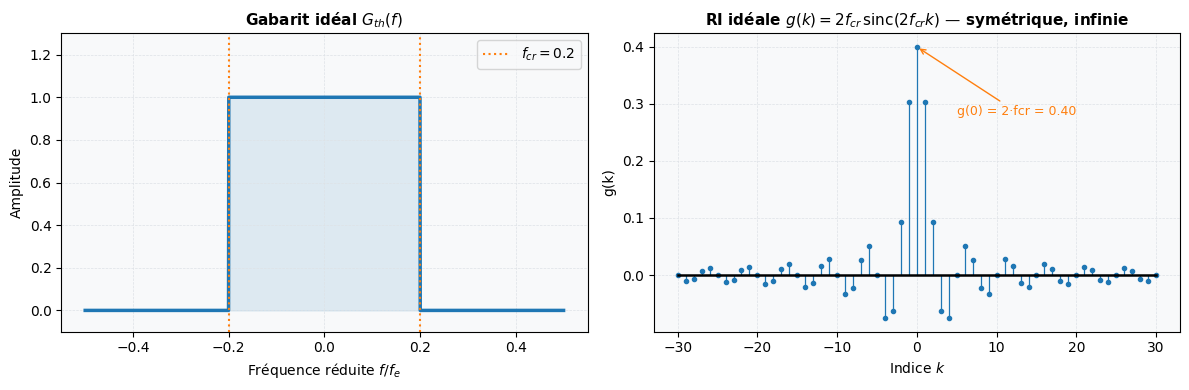

In [4]:
# Gabarit idéal (fréquences réduites)
f_plot = np.linspace(-0.5, 0.5, 2000)
G_th   = np.where(np.abs(f_plot) <= fcr, 1.0, 0.0)

# g(k) sur ±30 coefficients
k_range = np.arange(-30, 31)
g_vals  = sinc_coeff(k_range, fcr)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Gabarit
ax = axes[0]
ax.fill_between(f_plot, G_th, alpha=0.12, color=C['ideal'])
ax.plot(f_plot, G_th, color=C['ideal'], lw=2.5)
ax.axvline( fcr, color=C['rect'], ls=':', lw=1.5, label=f'$f_{{cr}}={fcr}$')
ax.axvline(-fcr, color=C['rect'], ls=':', lw=1.5)
ax.set(xlabel='Fréquence réduite $f/f_e$', ylabel='Amplitude',
       title='Gabarit idéal $G_{th}(f)$', xlim=(-0.55, 0.55), ylim=(-0.1, 1.3))
ax.legend()

# Réponse impulsionnelle g(k)
ax = axes[1]
ml, sl, bl = ax.stem(k_range, g_vals, markerfmt='o', linefmt='-', basefmt='k-')
plt.setp(sl, color=C['ideal'], lw=0.9); plt.setp(ml, color=C['ideal'], ms=3)
ax.annotate(f'g(0) = 2·fcr = {2*fcr:.2f}', xy=(0, 2*fcr),
            xytext=(5, 0.28), fontsize=9, color=C['rect'],
            arrowprops=dict(arrowstyle='->', color=C['rect'], lw=1))
ax.set(xlabel='Indice $k$', ylabel='g(k)',
       title=r'RI idéale $g(k)=2f_{cr}\,\mathrm{sinc}(2f_{cr}k)$ — symétrique, infinie')

plt.tight_layout()
plt.show()

#### Interprétations : 

1) $g(k)$ est **symétrique**, c'est-à-dire $g(-k) = g(k)$.

    **Démonstration :**

    $$g(-k) = \frac{\sin(2\pi f_{cr}(-k))}{\pi(-k)} = \frac{-\sin(2\pi f_{cr}\,k)}{-\pi k} = \frac{\sin(2\pi f_{cr}\,k)}{\pi k} = g(k) \quad \checkmark$$

    **Pouvait-on s'y attendre ?**

    Oui. Le gabarit $G_{th}(f)$ est **réel et pair**, donc par propriété de la transformée de Fourier :

    $$G_{th}(f) \in \mathbb{R} \text{ et } G_{th}(-f) = G_{th}(f) \implies g(-k) = g(k)$$

    **La symétrie de $g(k)$ est ainsi une conséquence directe de la parité du gabarit.**
C'est aussi ce qui garantit une **phase nulle** (ou constante) pour le filtre non-causal.


2) $g(k)$ possède un nombre **infini** de coefficients non nuls, ce qui la rend **non implémentable** directement sur un calculateur (mémoire finie, temps de calcul infini).

Il est donc nécessaire de **tronquer** $g(k)$ à un nombre fini de $N$ termes à l'aide d'une **fenêtre** $w_N(k)$, ce qui constitue l'étape suivante de la synthèse.

---
### Étape 2 — Troncature par fenêtre rectangulaire

#### **Fonction de transfert $G_w(f)$ du filtre non-causal tronqué**

Comme $g(k)$ possède un nombre infini de termes, elle n'est pas directement implémentable en pratique. On la **tronque** en la multipliant par une fenêtre rectangulaire $w_N(k)$, qui vaut 1 sur $N$ termes centrés en $k=0$ et 0 partout ailleurs. On obtient la réponse impulsionnelle tronquée :

$$g_w(k) = w_N(k) \cdot g(k), \quad k \in \left\{-M, \ldots, 0, \ldots, +M\right\}$$

où $N$ est choisi **impair** et $M = \dfrac{N-1}{2}$ est le nombre de coefficients de chaque côté du centre. Ce choix garantit une séquence **symétrique et centrée en $k=0$**.

La fonction de transfert du filtre non-causal tronqué est la transformée de Fourier de $g_w(k)$ :

$$G_w(f) = \sum_{k=-M}^{+M} g_w(k)\,e^{-j2\pi f k T_e}$$

Puisque $g_w(k)$ est **symétrique** ($g_w(-k) = g_w(k)$), les termes $k$ et $-k$ se regroupent en cosinus (les parties imaginaires s'annulent deux à deux), ce qui simplifie l'expression en :

$$\boxed{G_w(f) = g_w(0) + \sum_{k=1}^{M} 2\,g_w(k)\cos(2\pi f k T_e)}$$

$G_w(f)$ est donc une somme de cosinus, donc une fonction **réelle**. Cela confirme que le filtre non-causal tronqué conserve une **phase nulle**

---

#### **Terme de phase linéaire pour rendre le filtre causal**

Un filtre dont la réponse impulsionnelle $g_w(k)$ est centrée en $k=0$ est **non-causal** : il nécessiterait de connaître des échantillons futurs du signal ($k < 0$), ce qui est impossible en pratique.

Pour le rendre **causal**, on décale la réponse impulsionnelle de $M$ échantillons vers la droite :

$$h(n) = g_w(n - M)$$

Ce décalage temporel de $M = \dfrac{N-1}{2}$ échantillons correspond, dans le domaine fréquentiel, à une **multiplication par un terme de déphasage linéaire** (propriété du décalage de la transformée de Fourier) :

$$H(f) = G_w(f)\,e^{j\varphi(f)}$$

avec :

$$\boxed{\varphi(f) = -2\pi f M T_e = -\pi(N-1)\frac{f}{f_e}}$$

Ce terme de phase est dit **linéaire** car il est proportionnel à $f$ : tous les composantes fréquentielles subissent le même **retard de groupe** $t_d = M\,T_e$, ce qui préserve la forme du signal filtré. C'est la propriété fondamentale des filtres FIR à **phase linéaire**.

#### Tracé de $g_w(k)$ et $G(f)$ pour $N \in \{9, 21, 41\}$ (fenêtre rectangulaire)

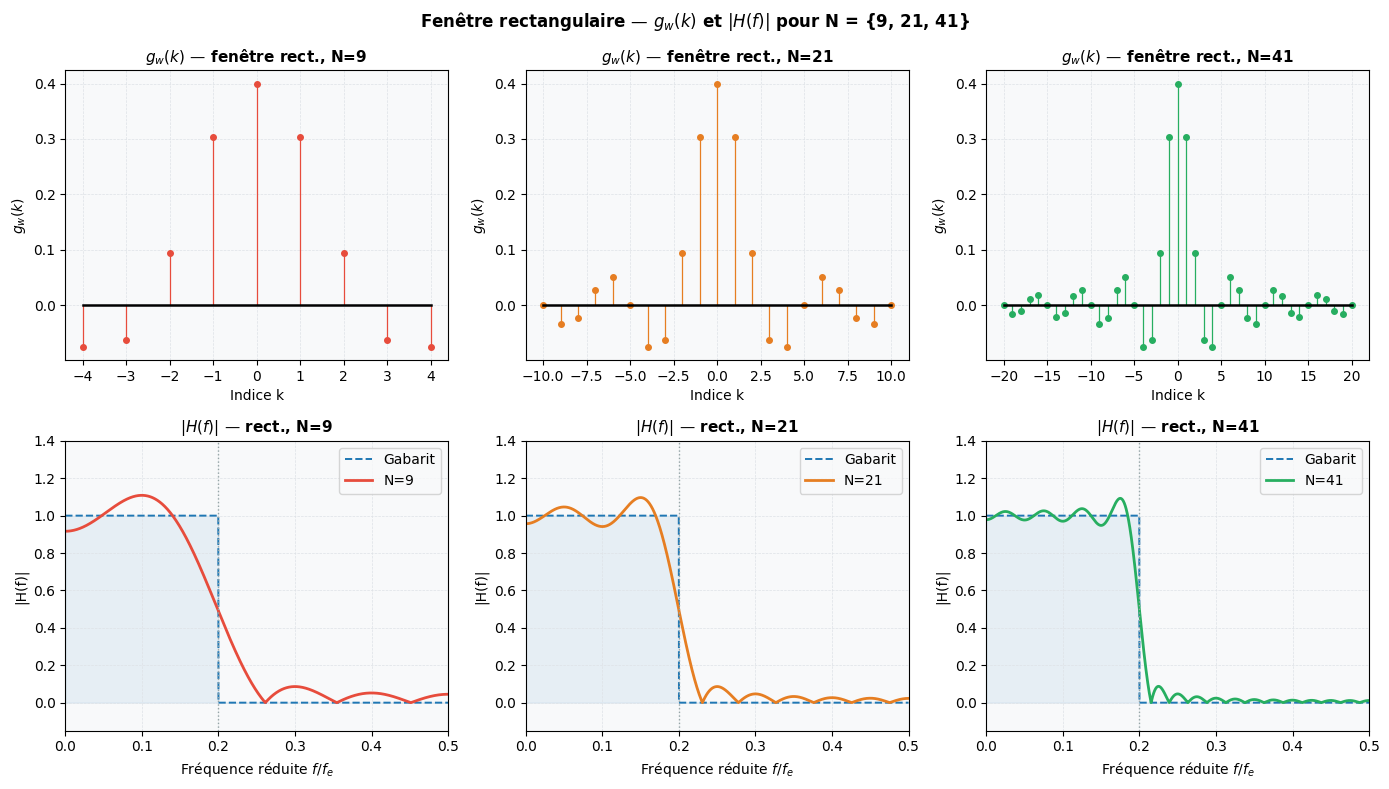

N= 9 → FIR_LP_4K_9N.txt  (9 coefficients sauvegardés)
N=21 → FIR_LP_4K_21N.txt  (21 coefficients sauvegardés)
N=41 → FIR_LP_4K_41N.txt  (41 coefficients sauvegardés)


In [6]:
N_vals  = [9, 21, 41]

# Gabarit idéal en fréquence réduite 0..0.5
f_red_plot = np.linspace(0, 0.5, 2000)
G_ideal    = np.where(f_red_plot <= fcr, 1.0, 0.0)


colors  = ['#E74C3C', '#E67E22', '#27AE60']
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle('Fenêtre rectangulaire — $g_w(k)$ et $|H(f)|$ pour N = {9, 21, 41}', fontweight='bold')

for col_idx, (N, col) in enumerate(zip(N_vals, colors)):
    h, gw, k_nc = make_fir(N, fcr, 'rect')
    np.savetxt(f'filt_coeff_rect_N{N}.txt', h)
    f_r, Hm, _ = freq_response(h, Nf)

    # Réponse impulsionnelle gw(k) non-causale
    ax = axes[0, col_idx]
    ml, sl, bl = ax.stem(k_nc, gw, markerfmt='o', linefmt='-', basefmt='k-')
    plt.setp(sl, color=col, lw=0.9); plt.setp(ml, color=col, ms=4)
    ax.set(xlabel='Indice k', ylabel='$g_w(k)$',
           title=f'$g_w(k)$ — fenêtre rect., N={N}')

    # Réponse fréquentielle |H(f)|
    ax = axes[1, col_idx]
    ax.fill_between(f_red_plot, G_ideal, alpha=0.08, color=C['ideal'])
    ax.plot(f_red_plot, G_ideal, color=C['ideal'], lw=1.4, ls='--', label='Gabarit')
    ax.plot(f_r, Hm, color=col, lw=2, label=f'N={N}')
    ax.axvline(fcr, color='#95A5A6', ls=':', lw=1)
    ax.set(xlim=(0, 0.5), ylim=(-0.15, 1.4),
           xlabel='Fréquence réduite $f/f_e$', ylabel='|H(f)|',
           title=f'$|H(f)|$ — rect., N={N}')
    ax.legend()

plt.tight_layout()
plt.show()

# Sauvegarde des coefficients pour chaque N
for N in N_vals:
    h, _, _ = make_fir(N, fcr, 'rect')
    np.savetxt(f'FIR_LP_4K_{N}N.txt', h, header=f'Coefficients FIR passe-bas fc=4kHz, fenetre rect, N={N}', comments='# ')
    print(f'N={N:2d} → FIR_LP_4K_{N}N.txt  ({N} coefficients sauvegardés)')

#### Comparaison des réponses $|H(f)|$ — Conclusions

| N | Largeur bande de transition |
|---|---|
| 9  | Très large |
| 21 | Réduite |
| 41 | Étroite |

**À quoi attribuer les ondulations ?**

Multiplier $g(k)$ par une fenêtre rectangulaire dans le domaine temporel revient, dans le domaine fréquentiel, à **convoluer** le gabarit idéal $G_{th}(f)$ par la transformée de Fourier de cette fenêtre. Or la transformée de Fourier d'une fenêtre rectangulaire est un **sinc**, qui possède des lobes secondaires — c'est précisément ces lobes qui, après convolution, créent les ondulations observées dans la bande passante et la bande atténuée.

**Conclusion :** augmenter $N$ **réduit la bande de transition** — la réponse fréquentielle approche de plus en plus le gabarit idéal. En lisant directement sur le graphe :

| N | Bande Passante |
|---|---|
| 9  | $\approx 5000$ Hz  |
| 21 | $\approx 4400$ Hz  |
| 41 | $\approx 4100$ Hz  |

Plus $N$ est grand, plus la coupure est **abrupte** et proche du filtre idéal. La contrepartie est un filtre plus **coûteux en calcul** et en mémoire, puisqu'il faut stocker et convoluer $N$ coefficients à chaque échantillon.

À la fin, on sauvegarde les coefficients du filtre — c'est-à-dire la **réponse impulsionnelle** $h(n)$ — dans un fichier `.txt`. Ces coefficients **définissent entièrement le filtre numérique** : il suffit ensuite d'appliquer l'équation de convolution avec un signal d'entrée $x(n)$ pour effectuer le filtrage :

$$y(n) = \sum_{k=0}^{N-1} h(k)\cdot x(n-k)$$

#### Vérification du filtrage — Sortie $y(n)$ et spectre $|Y(f)|$ pour $N \in \{9, 21, 41\}$

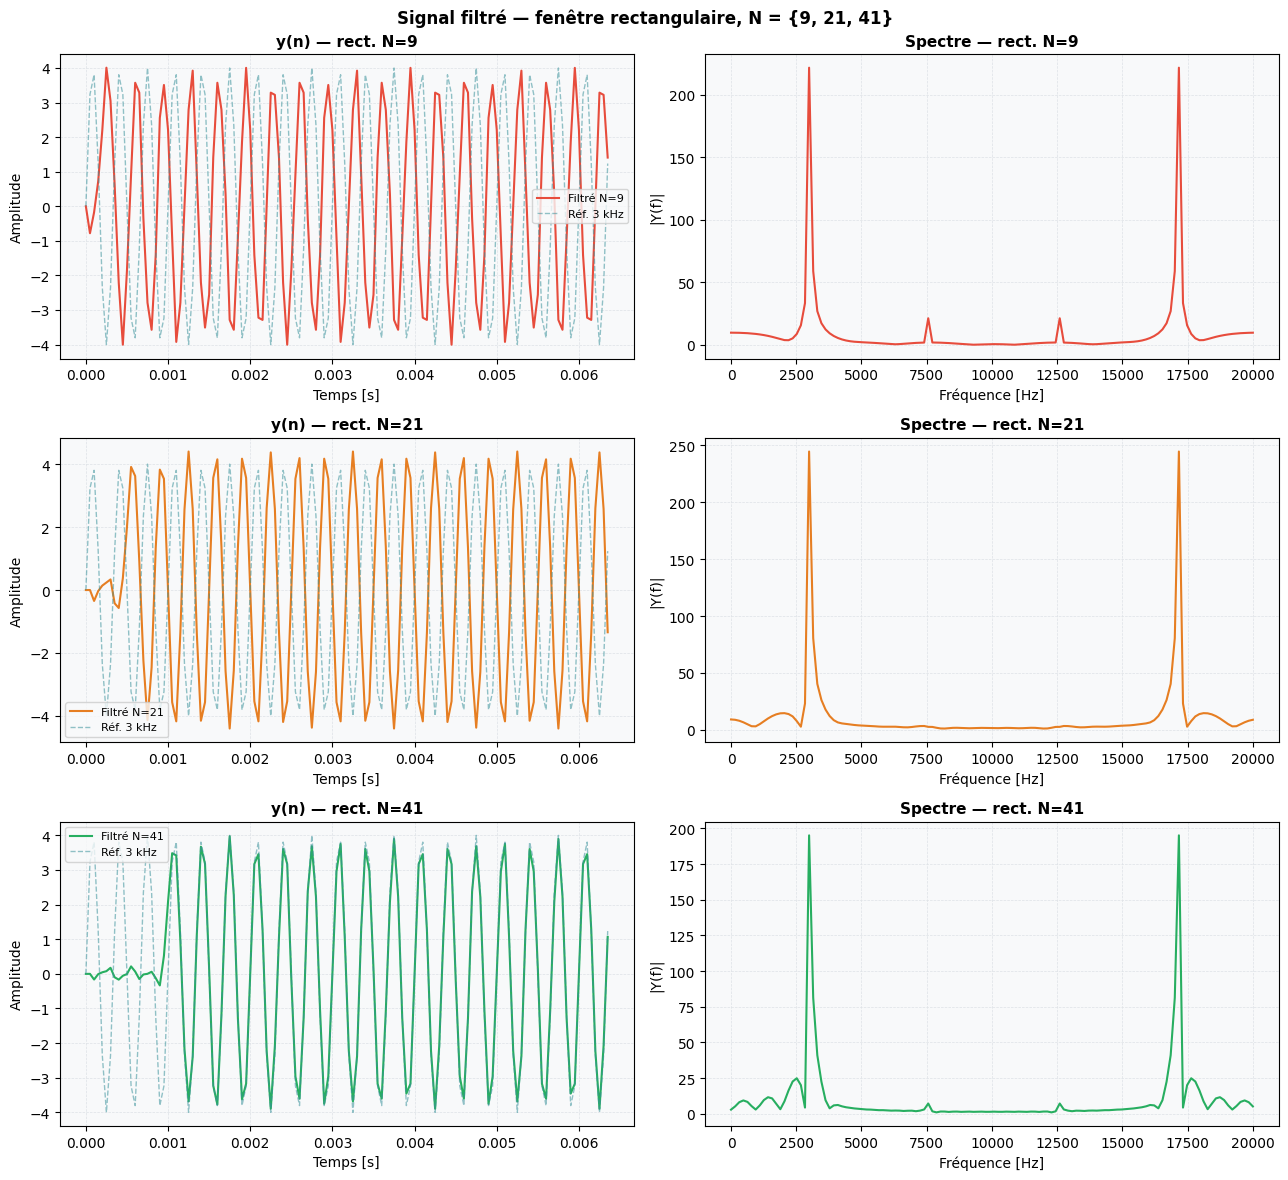

In [7]:
x    = np.loadtxt('in.txt')
t_ax = np.linspace(0, Np/fe, Np, endpoint=False)
f_ax = np.linspace(0, fe, Np)
ref3k = A1 * np.sin(2*np.pi*f1*t_ax)

fig, axes = plt.subplots(len(N_vals), 2, figsize=(13, 4*len(N_vals)))
fig.suptitle('Signal filtré — fenêtre rectangulaire, N = {9, 21, 41}', fontweight='bold')

for row, (N, col) in enumerate(zip(N_vals, colors)):
    # Chargement des coefficients depuis le fichier généré
    h = np.loadtxt(f'FIR_LP_4K_{N}N.txt')
    y = filtre_fir(x, h)

    axes[row, 0].plot(t_ax, y,     color=col,          lw=1.5, label=f'Filtré N={N}')
    axes[row, 0].plot(t_ax, ref3k, color=C['signal'],  lw=1.0, ls='--', alpha=0.55, label='Réf. 3 kHz')
    axes[row, 0].set(xlabel='Temps [s]', ylabel='Amplitude', title=f'y(n) — rect. N={N}')
    axes[row, 0].legend(fontsize=8)

    axes[row, 1].plot(f_ax, np.abs(fft(y)), color=col, lw=1.5)
    axes[row, 1].set(xlabel='Fréquence [Hz]', ylabel='|Y(f)|', title=f'Spectre — rect. N={N}')

plt.tight_layout()
plt.show()

---
### Fenêtre de Hamming

**Réduction des ondulations avec la fenêtre de Hamming**

La fenêtre de Hamming est définie par :
$$w(k) = 0{,}54 + 0{,}46\cos\!\left(\frac{2\pi k}{N-1}\right), \quad k \in \left[-\frac{N-1}{2},\,+\frac{N-1}{2}\right]$$

**Effet :** les ondulations (phénomène de Gibbs) sont fortement réduites car la fenêtre
atténue progressivement les extrémités de la réponse impulsionnelle. 
**Contrepartie :** la bande de transition est **plus large** qu'avec la fenêtre rectangulaire.

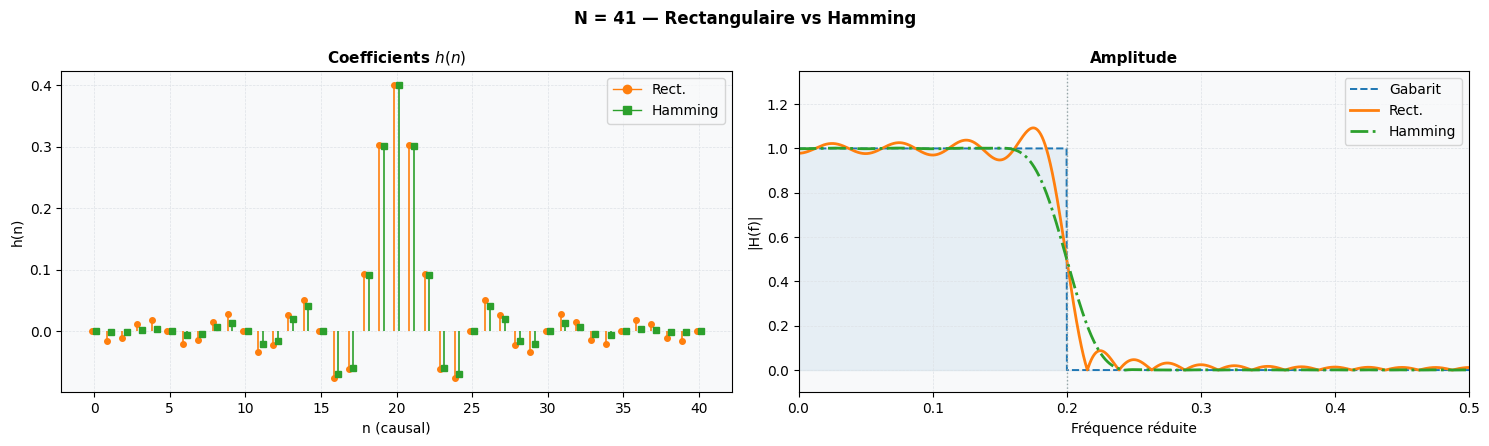

In [10]:
N_best = 41
h_r,   gw_r,   k_nc = make_fir(N_best, fcr, 'rect')
h_ham, gw_ham, _    = make_fir(N_best, fcr, 'hamming')

f_r,  Hr_mag,  _ = freq_response(h_r,   Nf)
f_h,  Hh_mag,  _ = freq_response(h_ham, Nf)

fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
fig.suptitle(f'N = {N_best} — Rectangulaire vs Hamming', fontweight='bold')

# Coefficients
ax = axes[0]
n  = np.arange(N_best)
ml, sl, _ = ax.stem(n - 0.15, h_r,   markerfmt='o', linefmt='-', basefmt=' ')
plt.setp(sl, color=C['rect'],    lw=1.2); plt.setp(ml, color=C['rect'],    ms=4)
ml, sl, _ = ax.stem(n + 0.15, h_ham, markerfmt='s', linefmt='-', basefmt=' ')
plt.setp(sl, color=C['hamming'], lw=1.2); plt.setp(ml, color=C['hamming'], ms=4)
ax.legend(handles=[
    Line2D([],[],color=C['rect'],    marker='o', lw=1, label='Rect.'),
    Line2D([],[],color=C['hamming'], marker='s', lw=1, label='Hamming'),
])
ax.set(xlabel='n (causal)', ylabel='h(n)', title='Coefficients $h(n)$')

# Amplitude linéaire
ax = axes[1]
ax.fill_between(f_red_plot, G_ideal, alpha=0.08, color=C['ideal'])
ax.plot(f_red_plot, G_ideal, color=C['ideal'],   lw=1.4, ls='--', label='Gabarit')
ax.plot(f_r, Hr_mag, color=C['rect'],    lw=2,          label='Rect.')
ax.plot(f_h, Hh_mag, color=C['hamming'], lw=2, ls='-.', label='Hamming')
ax.axvline(fcr, color='#95A5A6', ls=':', lw=1)
ax.set(xlim=(0,0.5), ylim=(-0.1,1.35),
       xlabel='Fréquence réduite', ylabel='|H(f)|', title='Amplitude')
ax.legend()

plt.tight_layout()
plt.show()

#### **Vérification du filtrage avec fenêtre de Hamming**

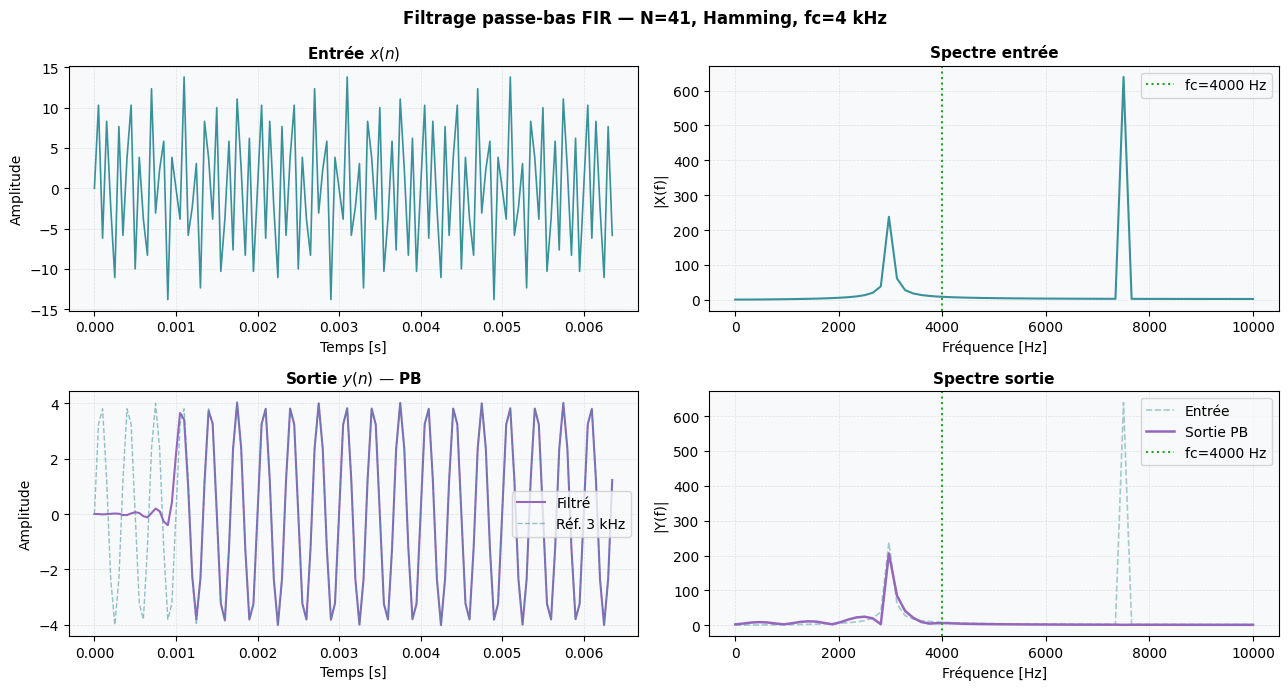

In [11]:
x    = np.loadtxt('in.txt')
h_pb = h_ham.copy()           # filtre PB N=41, Hamming
np.savetxt('filt_coeff.txt',  h_pb)   # fichier attendu par fir1.py
np.savetxt('filt_coeff_PB.txt', h_pb)

y_pb    = filtre_fir(x, h_pb)
freq_ax = np.fft.rfftfreq(Np, 1/fe)
S_in    = np.abs(np.fft.rfft(x))
S_pb    = np.abs(np.fft.rfft(y_pb))
t_ax    = np.linspace(0, Np/fe, Np, endpoint=False)
ref3k   = A1 * np.sin(2*np.pi*f1*t_ax)

fig, axes = plt.subplots(2, 2, figsize=(13, 7))
fig.suptitle('Filtrage passe-bas FIR — N=41, Hamming, fc=4 kHz', fontweight='bold')

axes[0,0].plot(t_ax, x,   color=C['signal'], lw=1.2)
axes[0,0].set(xlabel='Temps [s]', ylabel='Amplitude', title="Entrée $x(n)$")

axes[0,1].plot(freq_ax, S_in, color=C['signal'], lw=1.5)
axes[0,1].axvline(fc, color=C['hamming'], ls=':', lw=1.5, label=f'fc={fc} Hz')
axes[0,1].set(xlabel='Fréquence [Hz]', ylabel='|X(f)|', title='Spectre entrée')
axes[0,1].legend()

axes[1,0].plot(t_ax, y_pb,  color=C['filt'],   lw=1.5, label='Filtré')
axes[1,0].plot(t_ax, ref3k, color=C['signal'], lw=1.0, ls='--', alpha=0.55, label='Réf. 3 kHz')
axes[1,0].set(xlabel='Temps [s]', ylabel='Amplitude', title='Sortie $y(n)$ — PB')
axes[1,0].legend()

axes[1,1].plot(freq_ax, S_in, color=C['signal'], lw=1.2, ls='--', alpha=0.45, label='Entrée')
axes[1,1].plot(freq_ax, S_pb, color=C['filt'],   lw=1.8, label='Sortie PB')
axes[1,1].axvline(fc, color=C['hamming'], ls=':', lw=1.5, label=f'fc={fc} Hz')
axes[1,1].set(xlabel='Fréquence [Hz]', ylabel='|Y(f)|', title='Spectre sortie')
axes[1,1].legend()

plt.tight_layout()
plt.show()

#### Question 11 — Programme fir1.py complet (filtrage de in.txt)

---
## Partie 2 — Filtre passe-bande — Extraction de 7500 Hz

### Étape 1 — Filtre non-causal à phase nulle (passe-bande)

Le filtre passe-bande est construit par **différence de deux filtres passe-bas** :

$$G_{BP}(f) = G_{PL}(f) - G_{PH}(f)$$

avec $f_{low} = 6$ kHz et $f_{high} = 9$ kHz, soit les fréquences réduites :
$$f_{cr,low} = \frac{6000}{20000} = 0{,}30, \qquad f_{cr,high} = \frac{9000}{20000} = 0{,}45$$

La réponse impulsionnelle du passe-bande est alors :
$$g_{BP}(k) = 2f_{cr,high}\,\text{sinc}(2f_{cr,high}\,k) - 2f_{cr,low}\,\text{sinc}(2f_{cr,low}\,k)$$

$g_{BP}(k)$ est **symétrique** (différence de deux fonctions paires) → $G_{BP}(f)$ est **réelle**, phase nulle.

### Étape 2 — Troncature et causalité

On applique la fenêtre de Hamming à $g_{BP}(k)$ puis on décale de $M = \frac{N-1}{2}$ pour la causalité.
Le terme de phase linéaire est identique au cas passe-bas :
$$\varphi(f) = -\pi(N-1)\frac{f}{f_e}$$

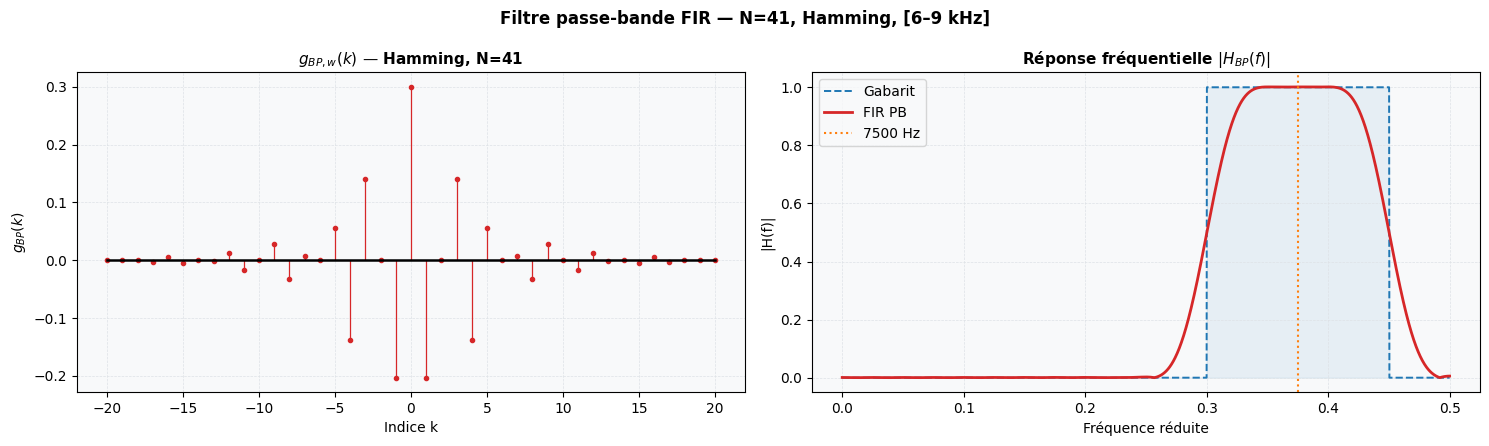

In [ ]:
f_low, f_high = 6000, 9000
fcr_low  = f_low  / fe     # 0.30
fcr_high = f_high / fe     # 0.45
N_bp = 41
M_bp = (N_bp - 1) // 2
k_bp = np.arange(-M_bp, M_bp + 1)

# Réponse impulsionnelle passe-bande (différence de deux sinc)
g_high = sinc_coeff(k_bp, fcr_high)
g_low  = sinc_coeff(k_bp, fcr_low)
g_bp   = g_high - g_low

# Fenêtre de Hamming
w_ham  = 0.54 + 0.46 * np.cos(2 * np.pi * k_bp / (N_bp - 1))
gw_bp  = g_bp * w_ham       # troncature par Hamming
h_bp   = gw_bp.copy()       # réponse causale
np.savetxt('filt_coeff_BP.txt', h_bp)

# Réponse fréquentielle
f_bp, Hbp_mag, _ = freq_response(h_bp, Nf)
G_bp_ideal = np.where((f_bp >= fcr_low) & (f_bp <= fcr_high), 1.0, 0.0)

fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
fig.suptitle(f'Filtre passe-bande FIR — N={N_bp}, Hamming, [{f_low/1e3:.0f}–{f_high/1e3:.0f} kHz]',
             fontweight='bold')

# Coefficients gw_bp(k)
ax = axes[0]
ml, sl, bl = ax.stem(k_bp, gw_bp, markerfmt='o', linefmt='-', basefmt='k-')
plt.setp(sl, color=C['pb'], lw=0.9); plt.setp(ml, color=C['pb'], ms=3)
ax.set(xlabel='Indice k', ylabel='$g_{BP}(k)$',
       title=f'$g_{{BP,w}}(k)$ — Hamming, N={N_bp}')

# |H_BP(f)| linéaire
ax = axes[1]
ax.fill_between(f_bp, G_bp_ideal, alpha=0.08, color=C['ideal'])
ax.plot(f_bp, G_bp_ideal,  color=C['ideal'], lw=1.4, ls='--', label='Gabarit')
ax.plot(f_bp, Hbp_mag,     color=C['pb'],    lw=2,          label='FIR PB')
ax.axvline(7500/fe, color=C['rect'], ls=':', lw=1.5, label='7500 Hz')
ax.set(xlabel='Fréquence réduite', ylabel='|H(f)|',
       title='Réponse fréquentielle $|H_{BP}(f)|$')
ax.legend()



plt.tight_layout()
plt.show()

### Filtrage du signal — Extraction de 7500 Hz (vérification)

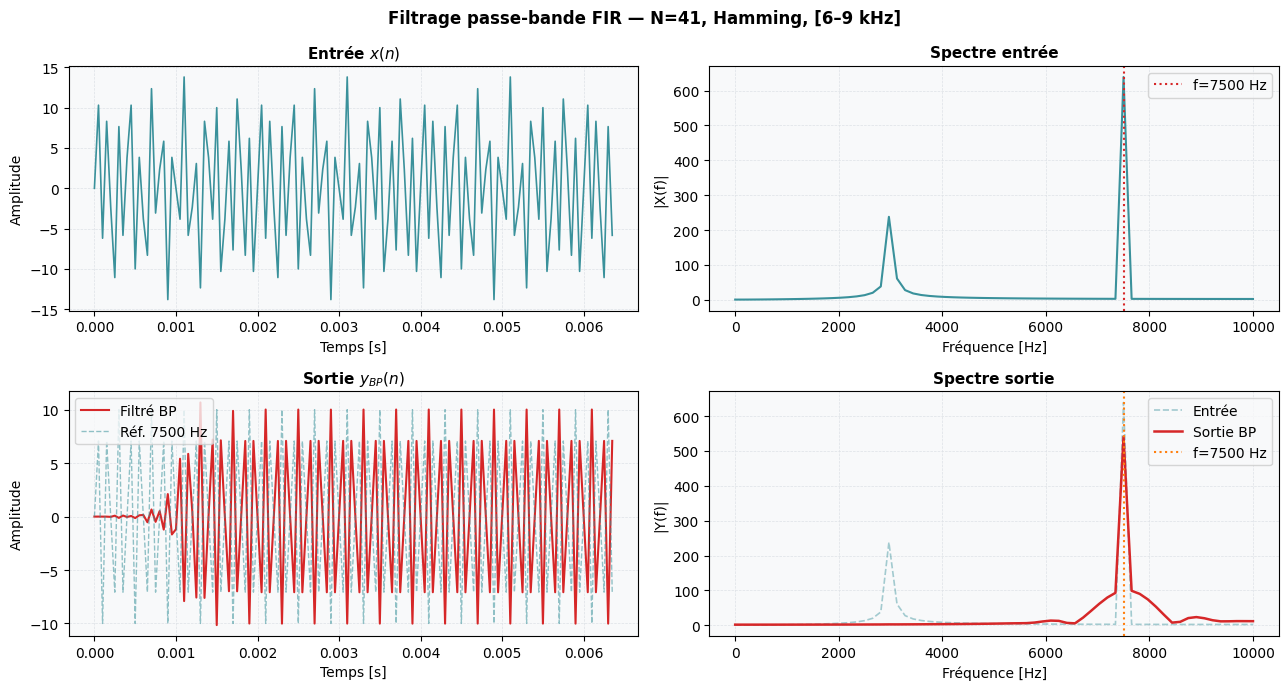

In [14]:
x    = np.loadtxt('in.txt')
y_bp = filtre_fir(x, h_bp)

freq_ax = np.fft.rfftfreq(Np, 1/fe)
S_in    = np.abs(np.fft.rfft(x))
S_bp    = np.abs(np.fft.rfft(y_bp))
t_ax    = np.linspace(0, Np/fe, Np, endpoint=False)
ref75k  = A2 * np.sin(2*np.pi*f2*t_ax)   # référence 7500 Hz

fig, axes = plt.subplots(2, 2, figsize=(13, 7))
fig.suptitle('Filtrage passe-bande FIR — N=41, Hamming, [6–9 kHz]', fontweight='bold')

axes[0,0].plot(t_ax, x, color=C['signal'], lw=1.2)
axes[0,0].set(xlabel='Temps [s]', ylabel='Amplitude', title="Entrée $x(n)$")

axes[0,1].plot(freq_ax, S_in, color=C['signal'], lw=1.5)
axes[0,1].axvline(f2, color=C['pb'], ls=':', lw=1.5, label=f'f={f2} Hz')
axes[0,1].set(xlabel='Fréquence [Hz]', ylabel='|X(f)|', title='Spectre entrée')
axes[0,1].legend()

axes[1,0].plot(t_ax, y_bp,   color=C['pb'],     lw=1.5, label='Filtré BP')
axes[1,0].plot(t_ax, ref75k, color=C['signal'], lw=1.0, ls='--', alpha=0.55, label='Réf. 7500 Hz')
axes[1,0].set(xlabel='Temps [s]', ylabel='Amplitude', title='Sortie $y_{BP}(n)$')
axes[1,0].legend()

axes[1,1].plot(freq_ax, S_in, color=C['signal'], lw=1.2, ls='--', alpha=0.45, label='Entrée')
axes[1,1].plot(freq_ax, S_bp, color=C['pb'],     lw=1.8, label='Sortie BP')
axes[1,1].axvline(f2, color=C['rect'], ls=':', lw=1.5, label=f'f={f2} Hz')
axes[1,1].set(xlabel='Fréquence [Hz]', ylabel='|Y(f)|', title='Spectre sortie')
axes[1,1].legend()

plt.tight_layout()
plt.show()